## Results from optimal_decay_trial1.jld2

In [5]:
using Plots, JLD2, LaTeXStrings, FileIO

# @load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/results_data/2atoms/optimal_decay_trial1.jld2"
@load "C:/Users/14aka/OneDrive/Documents/rydberg_qec/codework/results_data/2atoms/optimal_decay_trial1.jld2"

decay = decay
sweep_rate = sweep_rate
fidelity_end = fidelity_end
max_fidelity = max_fidelity;

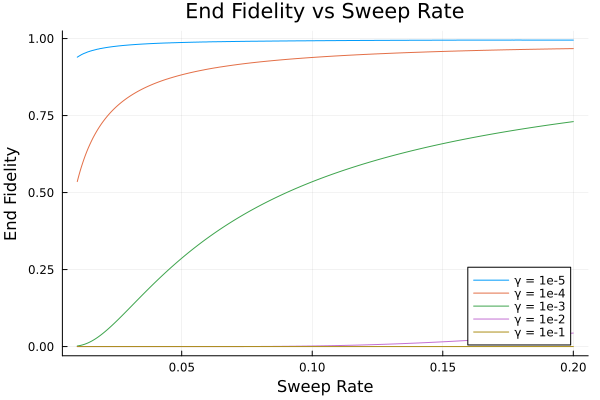

In [21]:
plot(sweep_rate,fidelity_end[1,:],label="γ = 1e-5",xlabel="Sweep Rate",ylabel="End Fidelity",title="End Fidelity vs Sweep Rate",legend=:bottomright)
plot!(sweep_rate,fidelity_end[2,:],label="γ = 1e-4")
plot!(sweep_rate,fidelity_end[3,:],label="γ = 1e-3")
plot!(sweep_rate,fidelity_end[4,:],label="γ = 1e-2")
plot!(sweep_rate,fidelity_end[5,:],label="γ = 1e-1")

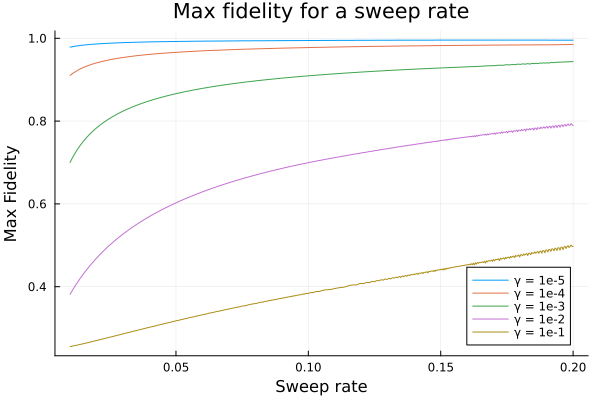

In [39]:
plot(sweep_rate,max_fidelity[1,:], label="γ = 1e-5", xlabel="Sweep rate", ylabel="Max Fidelity", title="Max fidelity for a sweep rate", legend=:bottomright)
plot!(sweep_rate,max_fidelity[2,:], label="γ = 1e-4", xlabel="Sweep rate", ylabel="Max Fidelity")
plot!(sweep_rate,max_fidelity[3,:], label="γ = 1e-3", xlabel="Sweep rate", ylabel="Max Fidelity")
plot!(sweep_rate,max_fidelity[4,:], label="γ = 1e-2", xlabel="Sweep rate", ylabel="Max Fidelity") 
plot!(sweep_rate,max_fidelity[5,:], label="γ = 1e-1", xlabel="Sweep rate", ylabel="Max Fidelity")

In [28]:
best_fidelity = []
best_sweep_rate = []
for i in 1:length(decay)
    push!(best_fidelity,maximum(max_fidelity[i,:]))
    push!(best_sweep_rate,sweep_rate[argmax(max_fidelity[i,:])])
end

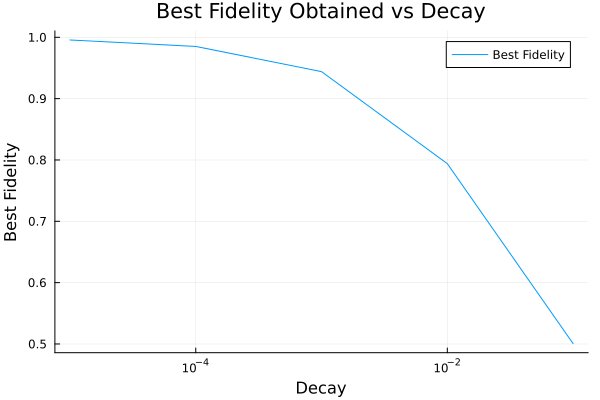

In [33]:
plot(decay,best_fidelity,xscale=:log10, label="Best Fidelity", xlabel="Decay", ylabel="Best Fidelity", title="Best Fidelity Obtained vs Decay", legend=:topright)

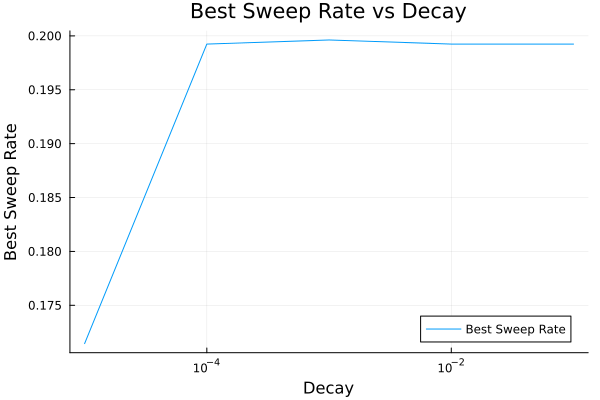

In [38]:
plot(decay,best_sweep_rate, xscale=:log10, label="Best Sweep Rate", xlabel="Decay", ylabel="Best Sweep Rate", title="Best Sweep Rate vs Decay", legend=:bottomright)

## Results from optimal_decay.jld2

In [57]:
using Plots, JLD2, LaTeXStrings, FileIO

@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/results_data/2atoms/optimal_decay.jld2"

decay = decay
sweep_rate = sweep_rate
fidelity = fidelity;

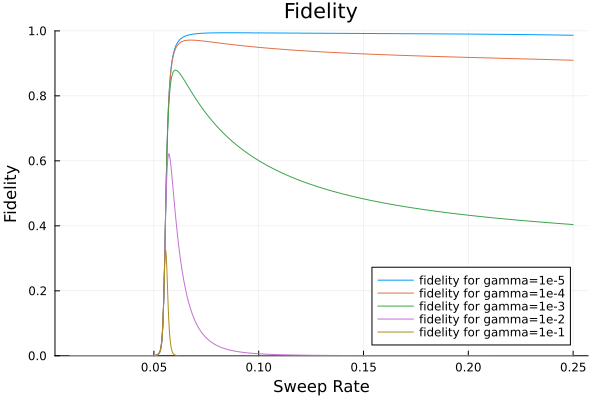

In [211]:
plot(sweep_rate,real(fidelity[1,:]),label="fidelity for gamma=1e-5",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity",legend=:bottomright)
plot!(sweep_rate,real(fidelity[2,:]),label="fidelity for gamma=1e-4",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
plot!(sweep_rate,real(fidelity[3,:]),label="fidelity for gamma=1e-3",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
plot!(sweep_rate,real(fidelity[4,:]),label="fidelity for gamma=1e-2",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
plot!(sweep_rate,real(fidelity[5,:]),label="fidelity for gamma=1e-1",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity")

In [353]:
# max_fidelity = []
# best_sweep_rate = []
# for i in 1:length(decay)

#     fidelity_wrt_sweeprate_for_decay = []

#     for j in 1:length(sweep_rate)

#         T_corresponding = 2*(1031-1000)/sweep_rate[490]

#         push!(fidelity_wrt_sweeprate_for_decay, (1 - exp(-1/sweep_rate[490])) * exp(-decay[i]*T_corresponding))

#     end
#     push!(max_fidelity,maximum(fidelity_wrt_sweeprate_for_decay))
#     push!(best_sweep_rate,sweep_rate[argmax(fidelity_wrt_sweeprate_for_decay)])
#     print(fidelity_wrt_sweeprate_for_decay)
# end

In [354]:
# plot(decay,max_fidelity,xscale=:log10,xaxis="Decay Rate",yaxis="Max Fidelity",title="Max Fidelity vs Decay Rate",label="Max Fidelity")

In [3]:
best_fidelity = []
best_sweep_rate = []
for i in 1:length(decay)
    # push!(best_fidelity,maximum(fidelity[i,:]))
    T_corresponding = 2*(1031-1000)/sweep_rate[i]
    push!(best_fidelity,fidelity[i,argmax(fidelity[i,:])] / exp(-decay[i]*291))
    push!(best_sweep_rate,sweep_rate[argmax(fidelity[i,:])])
end

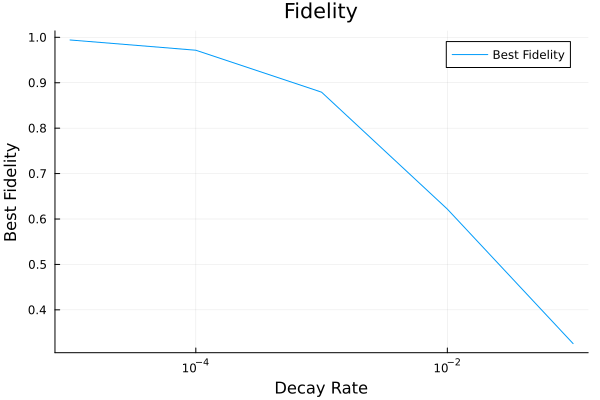

In [4]:
plot(decay,best_fidelity,xscale=:log10,label="Best Fidelity",xaxis="Decay Rate",yaxis="Best Fidelity",title="Fidelity")

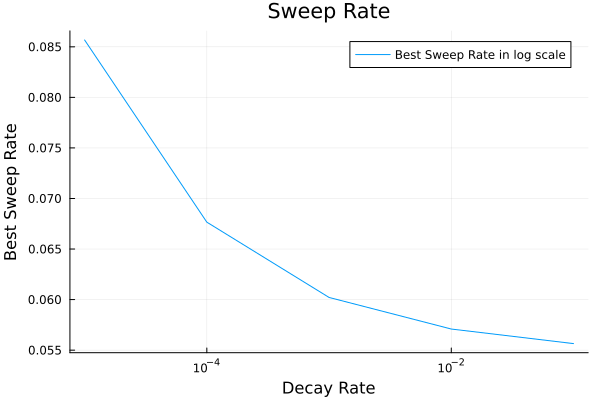

In [5]:
plot(decay,best_sweep_rate,xscale=:log10,label="Best Sweep Rate in log scale",xaxis="Decay Rate",yaxis="Best Sweep Rate",title="Sweep Rate")

## Analytical Decay

In [341]:
l = length(decay)
m = length(sweep_rate)

analytical_fidelity = Array{Float64}(undef,l,m)

Threads.@threads for idx in 1:l*m
    i = (idx-1) ÷ m + 1  # Calculate the row index
    j = (idx-1) % m + 1  # Calculate the column index

    a = decay[i]
    b = sweep_rate[j]
    # analytical_fidelity[i,j] = real(compute_I(b, a)) * (1 - exp(-2*pi*1^2/b))
    T = 2*(1031-1000)/b
    analytical_fidelity[i,j] = real((1 - exp(-1/b)) * exp(-a * 1))
end

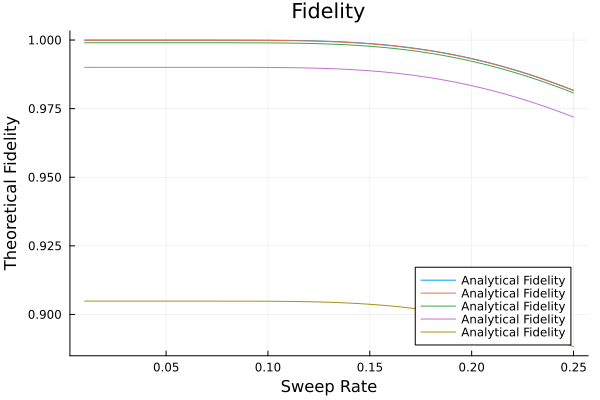

In [342]:
plot(sweep_rate,analytical_fidelity[1,:],label="Analytical Fidelity",xaxis="Sweep Rate",yaxis="Theoretical Fidelity",title="Fidelity",legend=:bottomright)
plot!(sweep_rate,analytical_fidelity[2,:],label="Analytical Fidelity",xaxis="Sweep Rate",yaxis="Theoretical Fidelity",title="Fidelity",legend=:bottomright)
plot!(sweep_rate,analytical_fidelity[3,:],label="Analytical Fidelity",xaxis="Sweep Rate",yaxis="Theoretical Fidelity",title="Fidelity",legend=:bottomright)
plot!(sweep_rate,analytical_fidelity[4,:],label="Analytical Fidelity",xaxis="Sweep Rate",yaxis="Theoretical Fidelity",title="Fidelity",legend=:bottomright)
plot!(sweep_rate,analytical_fidelity[5,:],label="Analytical Fidelity",xaxis="Sweep Rate",yaxis="Theoretical Fidelity",title="Fidelity",legend=:bottomright)